In [1]:
%load_ext autoreload
%autoreload 2

# PatchCore — features pré-entraînées (alternative à l'auto-encodeur)

Suite de [tp_deep_learning.ipynb](tp_deep_learning.ipynb) (voir aussi le
[rapport](tp_deep_learning_report.md)) : au lieu d'apprendre à **reconstruire** les images, on compare les
features d'un CNN **pré-entraîné** (gelé, non ré-entraîné sur nos données) à une mémoire de patchs saines.
Le score d'anomalie d'un patch = distance à son plus proche voisin dans cette mémoire ; le score d'une
image = le pire de ses patchs.

## Chargement des données

Mêmes jeux prétraités qu'en partie 2 (`screw/*.bin.gz`).

In [2]:
import gzip
from pathlib import Path

import numpy as np

DATA_DIR = Path('screw')
IMG_SIZE = 128
SEED = 42


def load_bin_gz(path, img_size=IMG_SIZE):
    with gzip.open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype='float32')
    return data.reshape(-1, img_size, img_size, 1)


X_train_norm = load_bin_gz(DATA_DIR / 'train_norm.bin.gz')
test_good_norm = load_bin_gz(DATA_DIR / 'test_good_norm.bin.gz')
test_defects_norm_stacked = load_bin_gz(DATA_DIR / 'test_defects_norm.bin.gz')

print('Train (normé)  :', X_train_norm.shape, X_train_norm.dtype)
print('Test saines    :', test_good_norm.shape)
print('Test défauts   :', test_defects_norm_stacked.shape)

Train (normé)  : (256, 128, 128, 1) float32
Test saines    : (41, 128, 128, 1)
Test défauts   : (119, 128, 128, 1)


## Extraction de features

`ResNet50` pré-entraîné sur ImageNet, tronqué à une couche intermédiaire (`conv3_block4_out`, stride 8).
Nos images sont en niveaux de gris (128×128×1) : on les convertit en RGB et on les redimensionne à la
taille attendue par le réseau avant de les passer dans le backbone (gelé — pas d'entraînement).

In [3]:
import tensorflow as tf
from tensorflow import keras

BACKBONE_SIZE = 224
LAYER_NAME = 'conv3_block4_out'  # stride 8 -> grille 28x28 pour une entrée 224x224

backbone = keras.applications.ResNet50(
    weights='imagenet', include_top=False, input_shape=(BACKBONE_SIZE, BACKBONE_SIZE, 3)
)
feature_extractor = keras.Model(backbone.input, backbone.get_layer(LAYER_NAME).output)
feature_extractor.trainable = False


def extract_patch_features(images, batch_size=32):
    """images (N, H, W, 1) dans [0, 1] -> features patch (N, h, w, C)."""
    rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(images))
    rgb = tf.image.resize(rgb, (BACKBONE_SIZE, BACKBONE_SIZE))
    rgb = keras.applications.resnet50.preprocess_input(rgb * 255.0)
    return feature_extractor.predict(rgb, batch_size=batch_size, verbose=0)


sample = extract_patch_features(X_train_norm[:1])
print('Grille de patchs :', sample.shape[1:3], '| dimension des features :', sample.shape[-1])

Grille de patchs : (28, 28) | dimension des features : 512


## Mémoire de patchs saines

On extrait les features de **toutes** les images saines d'entraînement, on aplatit en patchs, puis on
sous-échantillonne (la mémoire complète serait trop grande pour une recherche de plus proche voisin rapide
dans ce notebook — l'article original utilise une sélection *coreset* plus fine, ici un simple
sous-échantillonnage aléatoire).

In [4]:
MEMORY_SIZE = 10_000

train_features = extract_patch_features(X_train_norm)
n, h, w, c = train_features.shape
memory_bank_full = train_features.reshape(-1, c)

rng = np.random.default_rng(SEED)
subset_idx = rng.choice(len(memory_bank_full), size=min(MEMORY_SIZE, len(memory_bank_full)), replace=False)
memory_bank = memory_bank_full[subset_idx]

print(f'Mémoire : {memory_bank.shape} (sous-échantillonnée depuis {memory_bank_full.shape[0]} patchs)')

Mémoire : (10000, 512) (sous-échantillonnée depuis 200704 patchs)


## Score d'anomalie (plus proche voisin)

Pour chaque patch d'une image de test, on cherche son plus proche voisin dans la mémoire de patchs saines.
Le score de l'image = la **pire** distance parmi ses patchs (un seul patch anormal suffit à signaler
l'image, contrairement à une moyenne qui dilue le signal — même logique que le centile 99 côté
auto-encodeur).

In [5]:
from sklearn.neighbors import NearestNeighbors

nearest_neighbor = NearestNeighbors(n_neighbors=1).fit(memory_bank)


def anomaly_score(images):
    """Retourne le score par image (max des distances patch) et la carte de distances par patch."""
    features = extract_patch_features(images)
    n, h, w, c = features.shape
    flat = features.reshape(-1, c)
    distances, _ = nearest_neighbor.kneighbors(flat)
    distance_maps = distances.reshape(n, h, w)
    return distance_maps.max(axis=(1, 2)), distance_maps

In [6]:
errors_test_good, _ = anomaly_score(test_good_norm)
errors_test_defects, _ = anomaly_score(test_defects_norm_stacked)

print('Score (saines, test)  :', errors_test_good.shape)
print(f'  moyenne = {errors_test_good.mean():.3f}, écart-type = {errors_test_good.std():.3f}')
print('Score (défauts, test) :', errors_test_defects.shape)
print(f'  moyenne = {errors_test_defects.mean():.3f}, écart-type = {errors_test_defects.std():.3f}')

Score (saines, test)  : (41,)
  moyenne = 23.035, écart-type = 1.357
Score (défauts, test) : (119,)
  moyenne = 24.141, écart-type = 1.854


## Distribution des scores

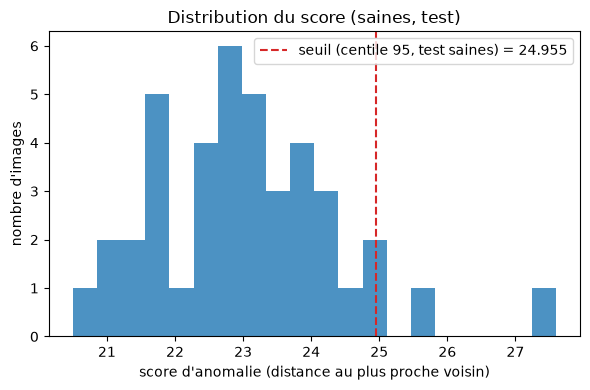

In [7]:
import matplotlib.pyplot as plt

threshold_p95 = np.percentile(errors_test_good, 95)

plt.figure(figsize=(6, 4))
plt.hist(errors_test_good, bins=20, color='tab:blue', alpha=0.8)
plt.axvline(threshold_p95, color='tab:red', linestyle='--', label=f'seuil (centile 95, test saines) = {threshold_p95:.3f}')
plt.xlabel('score d\'anomalie (distance au plus proche voisin)')
plt.ylabel("nombre d'images")
plt.title('Distribution du score (saines, test)')
plt.legend()
plt.tight_layout()
plt.show()

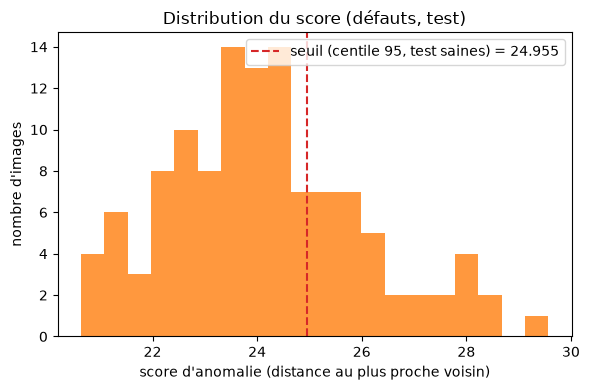

In [8]:
plt.figure(figsize=(6, 4))
plt.hist(errors_test_defects, bins=20, color='tab:orange', alpha=0.8)
plt.axvline(threshold_p95, color='tab:red', linestyle='--', label=f'seuil (centile 95, test saines) = {threshold_p95:.3f}')
plt.xlabel('score d\'anomalie (distance au plus proche voisin)')
plt.ylabel("nombre d'images")
plt.title('Distribution du score (défauts, test)')
plt.legend()
plt.tight_layout()
plt.show()

## ROC & matrice de confusion

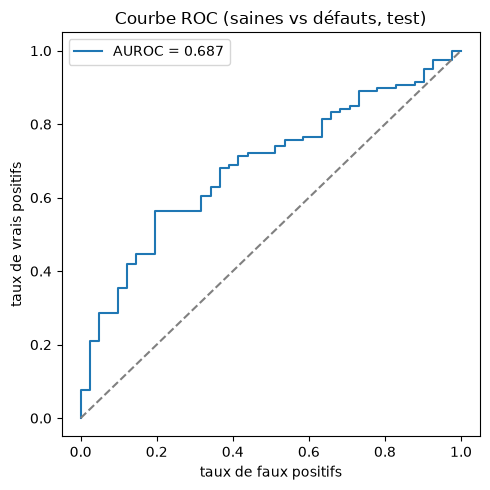

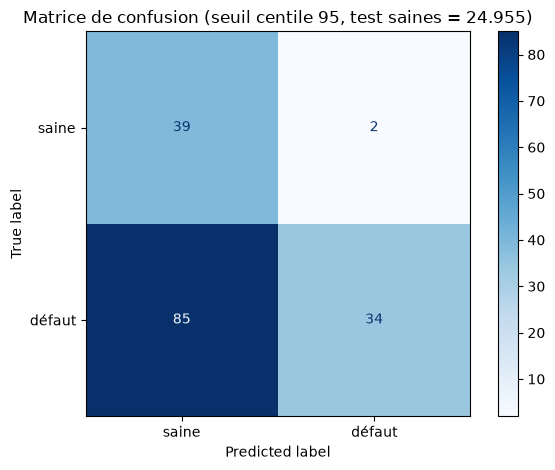

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, auc, confusion_matrix, roc_curve

y_true = np.concatenate([np.zeros(len(errors_test_good)), np.ones(len(errors_test_defects))])
y_score = np.concatenate([errors_test_good, errors_test_defects])

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'AUROC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('taux de faux positifs')
plt.ylabel('taux de vrais positifs')
plt.title('Courbe ROC (saines vs défauts, test)')
plt.legend()
plt.tight_layout()
plt.show()

y_pred = (y_score > threshold_p95).astype(int)
cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(cm, display_labels=['saine', 'défaut']).plot(cmap='Blues')
plt.title(f'Matrice de confusion (seuil centile 95, test saines = {threshold_p95:.3f})')
plt.tight_layout()
plt.show()

## Quel défaut est loupé ?

manipulated_front   : 19 loupé(s)
scratch_head        : 15 loupé(s)
scratch_neck        : 10 loupé(s)
thread_side         : 21 loupé(s)
thread_top          : 20 loupé(s)


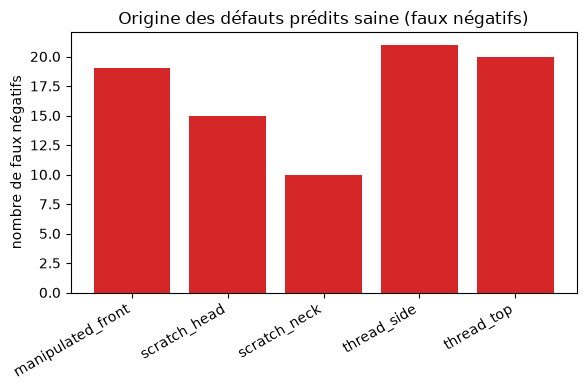

In [10]:
from collections import Counter

TEST_DIR = DATA_DIR / 'test'
defect_types = sorted(p.name for p in TEST_DIR.iterdir() if p.is_dir() and p.name != 'good')

# Catégorie de chaque indice de test_defects_norm_stacked (même ordre de concaténation qu'en partie 1 :
# catégories triées, fichiers triés dans chaque catégorie).
defect_category_per_index = []
for defect in defect_types:
    n_images = len(sorted((TEST_DIR / defect).glob('*.png')))
    defect_category_per_index += [defect] * n_images

n_good = len(errors_test_good)
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0] - n_good  # défaut → saine

missed_defect_types = [defect_category_per_index[i] for i in fn_idx]
counts = Counter(missed_defect_types)

for defect in defect_types:
    print(f'{defect:<20}: {counts.get(defect, 0)} loupé(s)')

plt.figure(figsize=(6, 4))
plt.bar(defect_types, [counts.get(d, 0) for d in defect_types], color='tab:red')
plt.ylabel('nombre de faux négatifs')
plt.title('Origine des défauts prédits saine (faux négatifs)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()